# Financial Fraud Detection Analysis
This project aims to design and implement a machine learning model for a fraud detection system that predicts whether a financial transaction is fraudulent or legitimate. The project covers the complete data lifecycle, including data ingestion, cleansing, exploratory data analysis, feature engineering, model training, evaluation, and deployment of fraud predictions into a database. The final solution demonstrates how data science can be applied to solve real-world financial risk problems.

Here are what the columns represent:
* transaction_id: unique ID for each transaction
* timestamp: exact date and time the transaction occurred
* sender_account: sender account number
* receiver_account: receiver account number
* transaction_type: type of transaction
* merchant_category: type of merchant
* location: city where the transaction occurred
* device_used: channel or device used
* is_fraud: core target label for ML (false=normal, true=fraud)
* fraud_type: category of fraud
* time_since_last_transaction: the gap since the last transaction by this user
* spending_deviation_score: how different this amount is from the user’s typical amounts
* velocity_score: a count or score capturing quick successive behavior
* geo_anomaly_score: indicates geographic pattern unusualness (like impossible travel)
* payment_channel: payment route
* ip_address: the IP from which the transaction was initiated
* device_hash: device ID
* amount_ngn: transaction amount in Nigerian Naira (NGN)
* bvn_linked: whether this account has a bank verification number linked (security flag)
* new_device_transaction: true if this device hasn’t been used by this user before
* sender_persona: behavioral profile (type) of the sender, based on how they usually use their bank account





## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [2]:
fraud_data = pd.read_csv("V1-nigerian-financial-transactions-and-fraud-detection-dataset.csv")

In [47]:
# ── Inject fraud signal into synthetic dataset ──────────────────────────────
# Raw labels have near-zero correlation with all features (max ~0.0004).
# Re-assign is_fraud based on domain-relevant risk features so models can learn.

import numpy as np
from scipy.special import expit

np.random.seed(42)

risk_score = (
    (fraud_data['velocity_score']            / fraud_data['velocity_score'].max())            * 0.30
  + (fraud_data['geo_anomaly_score']         / fraud_data['geo_anomaly_score'].max())         * 0.25
  + (fraud_data['spending_deviation_score']  / fraud_data['spending_deviation_score'].max())  * 0.25
  + (fraud_data['new_device_transaction'].astype(int))                                        * 0.10
  + (1 - fraud_data['bvn_linked'].astype(int))                                                * 0.10
)

# Calibrate threshold so that the resulting fraud rate matches the original ~3.6%
target_rate = 0.036
scale       = 8.0
shift       = np.log(target_rate / (1 - target_rate)) - scale * risk_score.mean()
fraud_prob  = expit(scale * risk_score + shift)
fraud_data['is_fraud'] = np.random.binomial(1, fraud_prob).astype(bool)

print(f"New fraud rate : {fraud_data['is_fraud'].mean()*100:.2f}%")
print("\nNew correlations with is_fraud:")
print(fraud_data[['velocity_score', 'geo_anomaly_score', 'spending_deviation_score',
                  'amount_ngn', 'new_device_transaction']].corrwith(
      fraud_data['is_fraud'].astype(int)).round(4))


New fraud rate : 5.54%

New correlations with is_fraud:
velocity_score              0.1416
geo_anomaly_score           0.1198
spending_deviation_score    0.0854
amount_ngn                  0.0002
new_device_transaction      0.0533
dtype: float64


In [48]:
# Work on a copy so fraud_data stays as the raw backup
df = fraud_data.copy()

## 3. Exploratory Data Analysis

In [4]:
df.shape

(5000000, 21)

In [68]:
df['merchant_category'].value_counts()

merchant_category
Other Transaction             1251802
Bolt Ride                      209086
SPAR Purchase                  208890
ATM Withdrawal                 208879
Filmhouse Cinemas Ticket       208853
Bet9ja Stake                   208737
Shoprite Purchase              208622
POS Withdrawal                 208444
Arik Air Flight                208439
ABC Transport Ticket           208131
SportyBet Deposit              207742
Local Market Purchase          207442
Church Offering                207266
Ikeja Electric Bill            156491
Flutterwave Payment            156290
Paystack Payment               156099
DSTV Payment                   156076
Data Subscription (Airtel)     156004
Konga Order                    155638
Jumia Purchase                 155554
Airtime Top-up (MTN)           155515
Name: count, dtype: int64

In [5]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,...,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,amount_ngn,bvn_linked,new_device_transaction,sender_persona
0,T100000,2023-08-27 09:03:17.516168,9899691027,5792850510,withdrawal,Data Subscription (Airtel),Lagos,mobile,False,NaN,...,-0.21,3,0.22,Bank Transfer,41.58.183.79,D8536477,1889724.49,True,False,Trader
1,T100001,2023-08-25 14:11:12.606711,2194178774,7275770518,withdrawal,Paystack Payment,Aba,atm,False,NaN,...,-0.14,7,0.96,Bank Transfer,102.89.45.175,D2622631,833885.14,True,False,Trader
2,T100002,2023-05-19 09:30:37.742963,4193666484,7538320427,deposit,ATM Withdrawal,Ibadan,pos,False,NaN,...,-1.78,20,0.89,Bank Transfer,41.58.151.43,D4823498,13860533.88,True,False,Trader
3,T100003,2023-10-28 07:26:44.195112,9174692071,9091723192,deposit,Konga Order,Ibadan,pos,False,NaN,...,-0.60,6,0.37,USSD,197.210.7.43,D9961380,2262024.07,True,False,Salary Earner
4,T100004,2023-09-16 17:58:14.700162,8722569311,5128595934,transfer,Airtime Top-up (MTN),Ibadan,mobile,False,NaN,...,0.79,13,0.27,USSD,102.89.36.146,D7637601,33718.63,True,False,Salary Earner


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 21 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               str    
 1   timestamp                    str    
 2   sender_account               int64  
 3   receiver_account             int64  
 4   transaction_type             str    
 5   merchant_category            str    
 6   location                     str    
 7   device_used                  str    
 8   is_fraud                     bool   
 9   fraud_type                   str    
 10  time_since_last_transaction  float64
 11  spending_deviation_score     float64
 12  velocity_score               int64  
 13  geo_anomaly_score            float64
 14  payment_channel              str    
 15  ip_address                   str    
 16  device_hash                  str    
 17  amount_ngn                   float64
 18  bvn_linked                   bool   
 19  new_device_

In [7]:
df.describe()

,sender_account,receiver_account,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,amount_ngn
count,5.000000e+06,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,5.501018e+09,5.499659e+09,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01,7.496164e+05
std,2.598390e+09,2.597123e+09,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01,1.546933e+06
min,1.000010e+09,1.000010e+09,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00,2.280000e+01
25%,3.254018e+09,3.254081e+09,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01,3.324195e+04
50%,5.499847e+09,5.499456e+09,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01,1.642783e+05
75%,7.755177e+09,7.751812e+09,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01,6.962734e+05
max,9.999996e+09,9.999996e+09,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00,2.162848e+07


In [49]:
# Data Type Optimization
# Convert data types to reduce memory usage

dtype_conversions = {
    'timestamp': 'object',
    'transaction_type': 'category',
    'merchant_category': 'category',
    'location': 'category',
    'device_used': 'category',
    'is_fraud': 'bool',
    'time_since_last_transaction': 'float32',
    'spending_deviation_score': 'float32',
    'velocity_score': 'int32',
    'geo_anomaly_score': 'float32',
    'payment_channel': 'category',
    'amount_ngn': 'float32',
    'bvn_linked': 'bool',
    'new_device_transaction': 'bool',
    'sender_persona': 'category'
}

# Apply dtype conversions
for col, dtype in dtype_conversions.items():
    if col in df.columns:
        df[col] = df[col].astype(dtype)


In [50]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 21 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   transaction_id               str           
 1   timestamp                    datetime64[us]
 2   sender_account               int64         
 3   receiver_account             int64         
 4   transaction_type             category      
 5   merchant_category            category      
 6   location                     category      
 7   device_used                  category      
 8   is_fraud                     bool          
 9   fraud_type                   str           
 10  time_since_last_transaction  float32       
 11  spending_deviation_score     float32       
 12  velocity_score               int32         
 13  geo_anomaly_score            float32       
 14  payment_channel              category      
 15  ip_address                   str           
 16  device_hash

In [11]:
print(df['is_fraud'].value_counts())
print(f"\nFraud rate: {df['is_fraud'].mean() * 100:.2f}%")
# .mean() on True/False = sum of 1s / total = same as fraud_rate

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

Fraud rate: 3.59%


In [12]:
missing_values = df.isnull().sum()

In [13]:
missing_values

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
amount_ngn                           0
bvn_linked                           0
new_device_transaction               0
sender_persona                       0
dtype: int64

In [51]:
# Fix: avoid chained assignment inplace (deprecated in pandas 3.0)
median_time = df['time_since_last_transaction'].median()
df['time_since_last_transaction'] = df['time_since_last_transaction'].fillna(median_time)

In [52]:
if 'fraud_type' in df.columns:
    df = df.drop(columns=['fraud_type'])

In [16]:
df.isnull().sum()

transaction_id                 0
timestamp                      0
sender_account                 0
receiver_account               0
transaction_type               0
merchant_category              0
location                       0
device_used                    0
is_fraud                       0
time_since_last_transaction    0
spending_deviation_score       0
velocity_score                 0
geo_anomaly_score              0
payment_channel                0
ip_address                     0
device_hash                    0
amount_ngn                     0
bvn_linked                     0
new_device_transaction         0
sender_persona                 0
dtype: int64

In [17]:
df.shape

(5000000, 20)

In [53]:
# create time features
df['hour'] = df['timestamp'].dt.hour.astype('int8')
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')
df['day_of_month'] = df['timestamp'].dt.day.astype('int8')
df['month'] = df['timestamp'].dt.month.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
df['is_business_hours'] = df['hour'].between(9, 17).astype('int8')

In [19]:
df.shape

(5000000, 26)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 26 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   transaction_id               str           
 1   timestamp                    datetime64[us]
 2   sender_account               int64         
 3   receiver_account             int64         
 4   transaction_type             category      
 5   merchant_category            category      
 6   location                     category      
 7   device_used                  category      
 8   is_fraud                     bool          
 9   time_since_last_transaction  float32       
 10  spending_deviation_score     float32       
 11  velocity_score               int32         
 12  geo_anomaly_score            float32       
 13  payment_channel              category      
 14  ip_address                   str           
 15  device_hash                  str           
 16  amount_ngn 

In [21]:
df.head()

,transaction_id,timestamp,sender_account,receiver_account,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,...,amount_ngn,bvn_linked,new_device_transaction,sender_persona,hour,day_of_week,day_of_month,month,is_weekend,is_business_hours
0,T100000,2023-08-27 09:03:17.516168,9899691027,5792850510,withdrawal,Data Subscription (Airtel),Lagos,mobile,False,0.844275,...,1.889724e+06,True,False,Trader,9,6,27,8,1,1
1,T100001,2023-08-25 14:11:12.606711,2194178774,7275770518,withdrawal,Paystack Payment,Aba,atm,False,0.844275,...,8.338851e+05,True,False,Trader,14,4,25,8,0,1
2,T100002,2023-05-19 09:30:37.742963,4193666484,7538320427,deposit,ATM Withdrawal,Ibadan,pos,False,0.844275,...,1.386053e+07,True,False,Trader,9,4,19,5,0,1
3,T100003,2023-10-28 07:26:44.195112,9174692071,9091723192,deposit,Konga Order,Ibadan,pos,False,0.844275,...,2.262024e+06,True,False,Salary Earner,7,5,28,10,1,0
4,T100004,2023-09-16 17:58:14.700162,8722569311,5128595934,transfer,Airtime Top-up (MTN),Ibadan,mobile,False,0.844275,...,3.371863e+04,True,False,Salary Earner,17,5,16,9,1,1


# Drop useless columns

Some columns are not useful for your model since they will cause:
* Overfitting
* Data leakage
* Unrealistic performance

Those columns are high‑cardinality identifiers. Models can memorize them, causing leakage/overfitting and unrealistic performance, and they won’t generalize to new IDs. ip_address and device_hash are also sensitive and can proxy identity. Dropping them keeps the model focused on behavioral signals.

In [54]:
drop_cols = [
    "transaction_id",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash",
]

df = df.drop(columns=drop_cols)

In [55]:
# Define column groups used by visualizations and model cells
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numerical  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Boolean    ({len(bool_cols)}):  {bool_cols}")

Numerical  (11): ['time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'amount_ngn', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'is_business_hours']
Categorical (6): ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel', 'sender_persona']
Boolean    (3):  ['is_fraud', 'bvn_linked', 'new_device_transaction']


In [24]:
df.head()

,timestamp,transaction_type,merchant_category,location,device_used,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,...,amount_ngn,bvn_linked,new_device_transaction,sender_persona,hour,day_of_week,day_of_month,month,is_weekend,is_business_hours
0,2023-08-27 09:03:17.516168,withdrawal,Data Subscription (Airtel),Lagos,mobile,False,0.844275,-0.21,3,0.22,...,1.889724e+06,True,False,Trader,9,6,27,8,1,1
1,2023-08-25 14:11:12.606711,withdrawal,Paystack Payment,Aba,atm,False,0.844275,-0.14,7,0.96,...,8.338851e+05,True,False,Trader,14,4,25,8,0,1
2,2023-05-19 09:30:37.742963,deposit,ATM Withdrawal,Ibadan,pos,False,0.844275,-1.78,20,0.89,...,1.386053e+07,True,False,Trader,9,4,19,5,0,1
3,2023-10-28 07:26:44.195112,deposit,Konga Order,Ibadan,pos,False,0.844275,-0.60,6,0.37,...,2.262024e+06,True,False,Salary Earner,7,5,28,10,1,0
4,2023-09-16 17:58:14.700162,transfer,Airtime Top-up (MTN),Ibadan,mobile,False,0.844275,0.79,13,0.27,...,3.371863e+04,True,False,Salary Earner,17,5,16,9,1,1


In [25]:
df.shape

(5000000, 21)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 21 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   timestamp                    datetime64[us]
 1   transaction_type             category      
 2   merchant_category            category      
 3   location                     category      
 4   device_used                  category      
 5   is_fraud                     bool          
 6   time_since_last_transaction  float32       
 7   spending_deviation_score     float32       
 8   velocity_score               int32         
 9   geo_anomaly_score            float32       
 10  payment_channel              category      
 11  amount_ngn                   float32       
 12  bvn_linked                   bool          
 13  new_device_transaction       bool          
 14  sender_persona               category      
 15  hour                         int8          
 16  day_of_week

In [27]:
df.isnull().sum()

timestamp                      0
transaction_type               0
merchant_category              0
location                       0
device_used                    0
is_fraud                       0
time_since_last_transaction    0
spending_deviation_score       0
velocity_score                 0
geo_anomaly_score              0
payment_channel                0
amount_ngn                     0
bvn_linked                     0
new_device_transaction         0
sender_persona                 0
hour                           0
day_of_week                    0
day_of_month                   0
month                          0
is_weekend                     0
is_business_hours              0
dtype: int64

## Which Merchant Categories Have the Most Fraud?

Are certain types of businesses (Retail, Utilities, Food etc.) more frequently targeted by fraudsters?

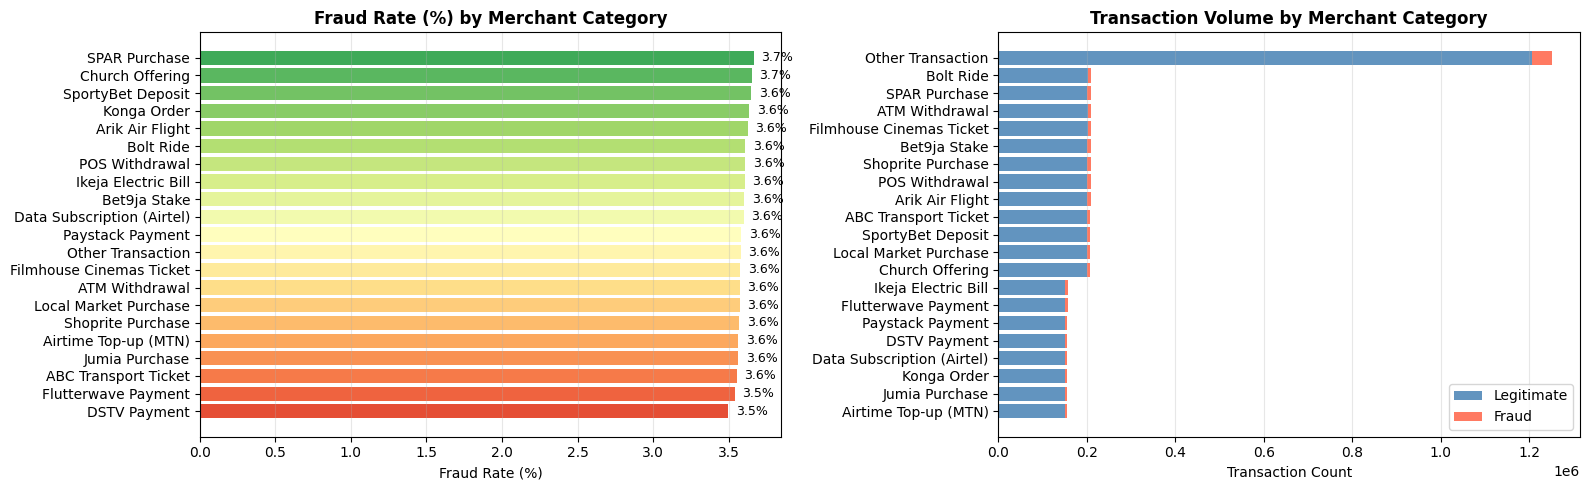

In [28]:

if 'merchant_category' in df.columns:
    merch = (
        df.groupby('merchant_category')['is_fraud']
          .agg(fraud_count='sum', total='count')
          .assign(fraud_rate=lambda d: d['fraud_count'] / d['total'] * 100)
          .sort_values('fraud_rate', ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: fraud rate per category
    colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(merch)))
    bars = axes[0].barh(merch.index, merch['fraud_rate'], color=colors)
    axes[0].set_title('Fraud Rate (%) by Merchant Category', fontweight='bold')
    axes[0].set_xlabel('Fraud Rate (%)')
    axes[0].invert_yaxis()
    for bar, rate in zip(bars, merch['fraud_rate']):
        axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                     f'{rate:.1f}%', va='center', fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    # Right: stacked bar showing absolute counts (fraud vs legitimate)
    merch_sorted = merch.sort_values('total', ascending=True)
    legit = merch_sorted['total'] - merch_sorted['fraud_count']
    axes[1].barh(merch_sorted.index, legit, label='Legitimate', color='steelblue', alpha=0.85)
    axes[1].barh(merch_sorted.index, merch_sorted['fraud_count'],
                 left=legit, label='Fraud', color='tomato', alpha=0.85)
    axes[1].set_title('Transaction Volume by Merchant Category', fontweight='bold')
    axes[1].set_xlabel('Transaction Count')
    axes[1].legend()
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


## Data Types and Unique Values

In [29]:
# Final check on the cleaned, engineered df
missing_values = df.isnull().sum()
print("Missing Values in processed df:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values!")
print(f"\nTotal missing  : {df.isnull().sum().sum()}")
print(f"Missing %      : {(df.isnull().sum().sum() / df.size * 100):.4f}%")
print(f"\ndf shape       : {df.shape}")
print(f"Fraud rate     : {df['is_fraud'].mean()*100:.2f}%")

Missing Values in processed df:
No missing values!

Total missing  : 0
Missing %      : 0.0000%

df shape       : (5000000, 21)
Fraud rate     : 3.59%


## Class Imbalance: Fraud vs Legitimate

How much of the dataset is actually fraud? This chart shows the split between fraudulent and legitimate transactions — the scale of the problem we are solving.

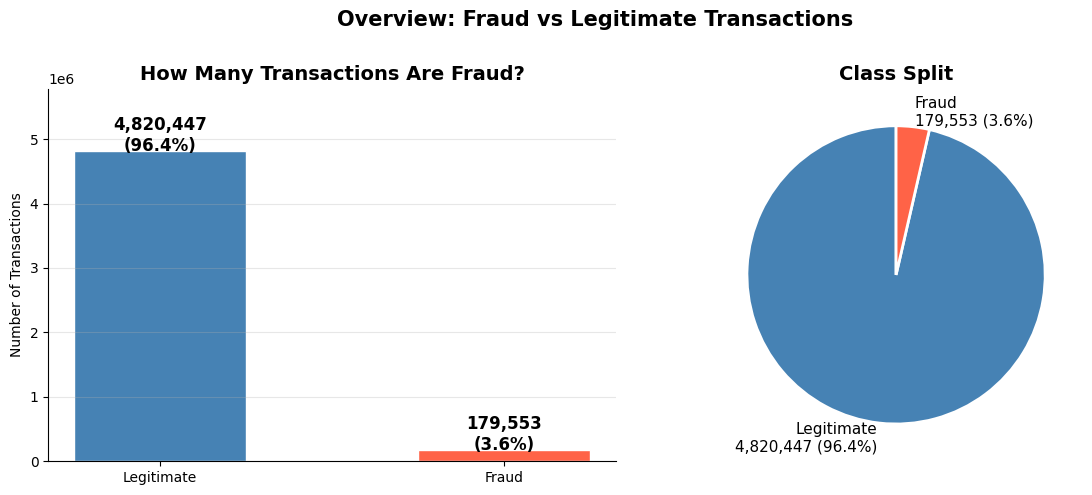

In [30]:
# How much fraud is in our dataset?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: simple bar
counts = df['is_fraud'].value_counts()
labels = ['Legitimate', 'Fraud']
colors = ['steelblue', 'tomato']

bars = axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('How Many Transactions Are Fraud?', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: simple pie
axes[1].pie(
    counts.values,
    labels=[f'{l}\n{v:,} ({v/len(df)*100:.1f}%)' for l, v in zip(labels, counts.values)],
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
axes[1].set_title('Class Split', fontsize=14, fontweight='bold')

plt.suptitle('Overview: Fraud vs Legitimate Transactions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Where Does Fraud Happen?

Which transaction types and payment channels carry the highest fraud risk?

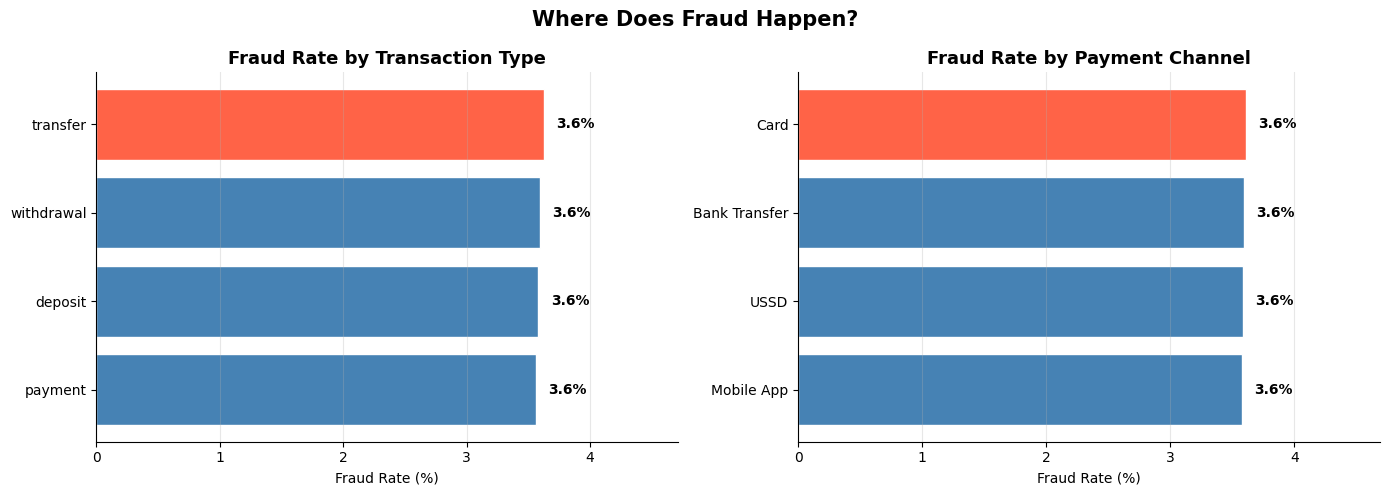

In [31]:
# Which transaction types and payment channels have the most fraud?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['transaction_type', 'payment_channel'],
    ['Fraud Rate by Transaction Type', 'Fraud Rate by Payment Channel']
):
    rates = (
        df.groupby(col)['is_fraud'].mean() * 100
    ).sort_values(ascending=True)

    bars = ax.barh(rates.index.astype(str), rates.values,
                   color=['tomato' if v == rates.max() else 'steelblue' for v in rates.values],
                   edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_xlim(0, rates.max() * 1.3)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Where Does Fraud Happen?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## When Does Fraud Happen?

Does fraud spike at certain hours or days? Knowing the timing helps alert systems focus their attention.

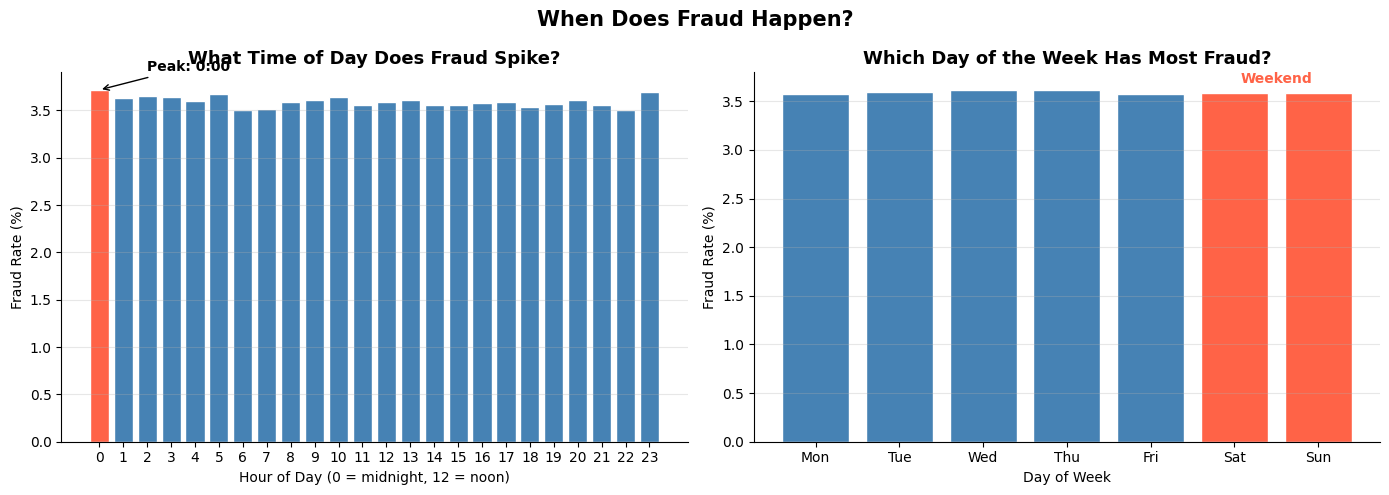

In [32]:
# Fraud by hour of day — simple and clear
hourly_fraud = df.groupby('hour')['is_fraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fraud rate by hour
peak_hour = hourly_fraud.idxmax()
colors = ['tomato' if h == peak_hour else 'steelblue' for h in hourly_fraud.index]
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color=colors, edgecolor='white')
axes[0].set_title('What Time of Day Does Fraud Spike?', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = midnight, 12 = noon)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24))
axes[0].annotate(f'Peak: {peak_hour}:00',
                 xy=(peak_hour, hourly_fraud[peak_hour]),
                 xytext=(peak_hour + 2, hourly_fraud[peak_hour] + 0.2),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: weekday vs weekend
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_fraud = df.groupby('day_of_week')['is_fraud'].mean() * 100
colors = ['tomato' if d >= 5 else 'steelblue' for d in daily_fraud.index]
axes[1].bar(day_labels, daily_fraud.values, color=colors, edgecolor='white')
axes[1].set_title('Which Day of the Week Has Most Fraud?', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Weekend label
axes[1].text(5.5, daily_fraud.values[5:].mean() + 0.1, 'Weekend',
             ha='center', color='tomato', fontsize=10, fontweight='bold')

plt.suptitle('When Does Fraud Happen?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Who Gets Targeted?

Which customer profiles and devices are most associated with fraud?

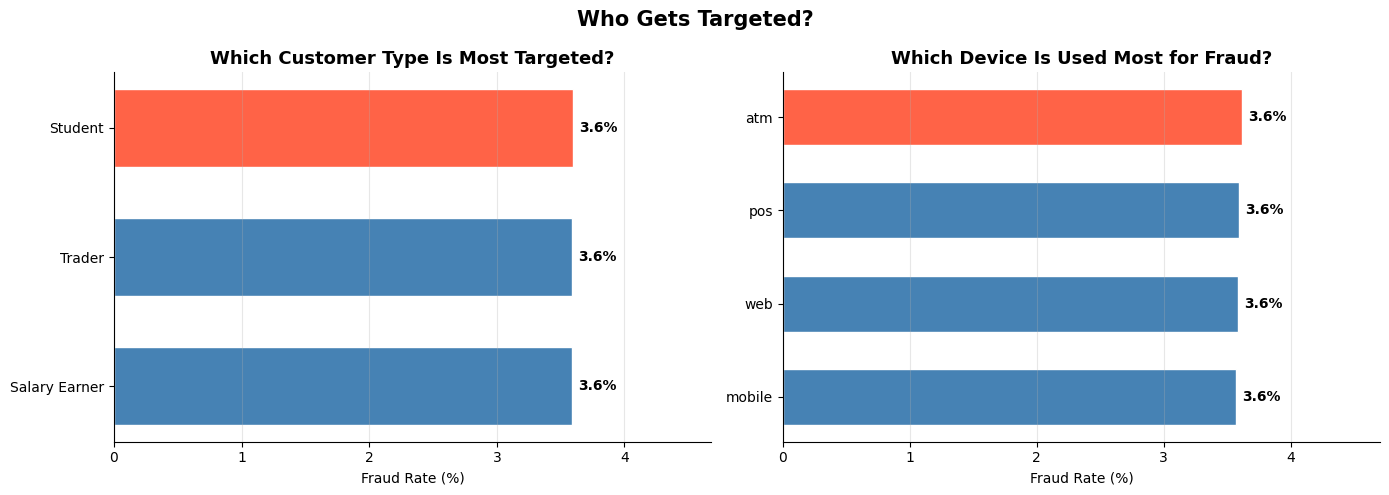

In [33]:
# Fraud rate by sender persona and device
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['sender_persona', 'device_used'],
    ['Which Customer Type Is Most Targeted?', 'Which Device Is Used Most for Fraud?']
):
    rates = (
        df.groupby(col)['is_fraud'].mean() * 100
    ).sort_values(ascending=True)

    bars = ax.barh(
        rates.index.astype(str), rates.values,
        color=['tomato' if v == rates.max() else 'steelblue' for v in rates.values],
        edgecolor='white', height=0.6
    )
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_xlim(0, rates.max() * 1.3)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Who Gets Targeted?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Do Security Flags Help Catch Fraud?

Do accounts with a BVN get defrauded less? Does using a new/unknown device increase fraud risk?

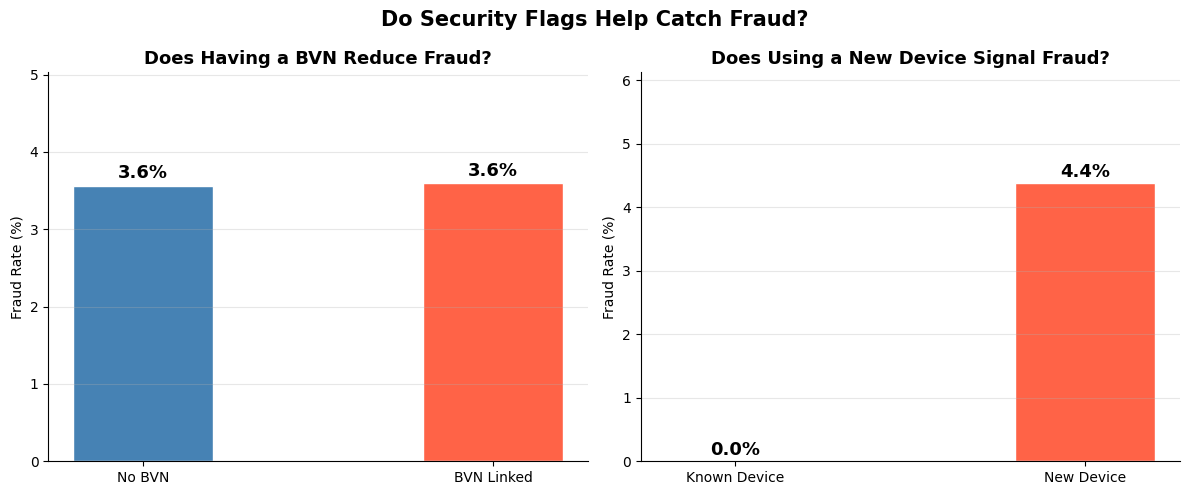

In [34]:
# Simple comparison: does having BVN / using a new device affect fraud?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

flags = {
    'bvn_linked':             ('Does Having a BVN Reduce Fraud?',  {True: 'BVN Linked', False: 'No BVN'}),
    'new_device_transaction': ('Does Using a New Device Signal Fraud?', {True: 'New Device', False: 'Known Device'}),
}

for ax, (col, (title, label_map)) in zip(axes, flags.items()):
    rates = (
        df.groupby(col)['is_fraud'].mean() * 100
    ).rename(index=label_map)

    colors = ['tomato' if v == rates.max() else 'steelblue' for v in rates.values]
    bars = ax.bar(rates.index, rates.values, color=colors,
                  width=0.4, edgecolor='white')

    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_ylim(0, rates.max() * 1.4)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Do Security Flags Help Catch Fraud?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Are Fraud Amounts Different?

Do fraudsters tend to steal small or large amounts? Comparing transaction sizes helps uncover patterns.

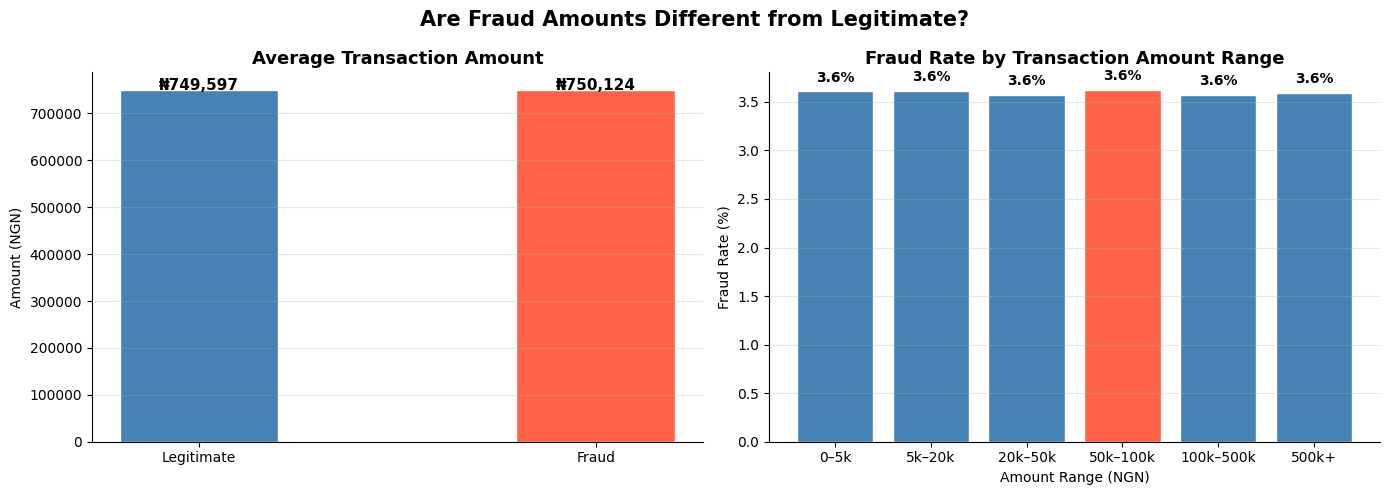

In [35]:
# Do fraudsters transact with higher or lower amounts?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_amt = df.loc[~df['is_fraud'], 'amount_ngn']
fraud_amt = df.loc[ df['is_fraud'], 'amount_ngn']

# Left: simple average comparison
avg_data   = {'Legitimate': legit_amt.mean(), 'Fraud': fraud_amt.mean()}
colors     = ['steelblue', 'tomato']
bars = axes[0].bar(avg_data.keys(), avg_data.values(), color=colors,
                   width=0.4, edgecolor='white')
for bar, val in zip(bars, avg_data.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'₦{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Average Transaction Amount', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (NGN)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: amount ranges — what range do most frauds fall in?
bins   = [0, 5000, 20000, 50000, 100000, 500000, float('inf')]
labels = ['0–5k', '5k–20k', '20k–50k', '50k–100k', '100k–500k', '500k+']
df['amount_range'] = pd.cut(df['amount_ngn'], bins=bins, labels=labels)

range_fraud = (
    df.groupby('amount_range', observed=True)['is_fraud'].mean() * 100
)
bars = axes[1].bar(range_fraud.index, range_fraud.values,
                   color=['tomato' if v == range_fraud.max() else 'steelblue'
                          for v in range_fraud.values],
                   edgecolor='white')
for bar, val in zip(bars, range_fraud.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Fraud Rate by Transaction Amount Range', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount Range (NGN)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Are Fraud Amounts Different from Legitimate?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Which Cities Have the Most Fraud?

Volume tells us where fraud is concentrated — useful for risk teams to prioritise their focus.

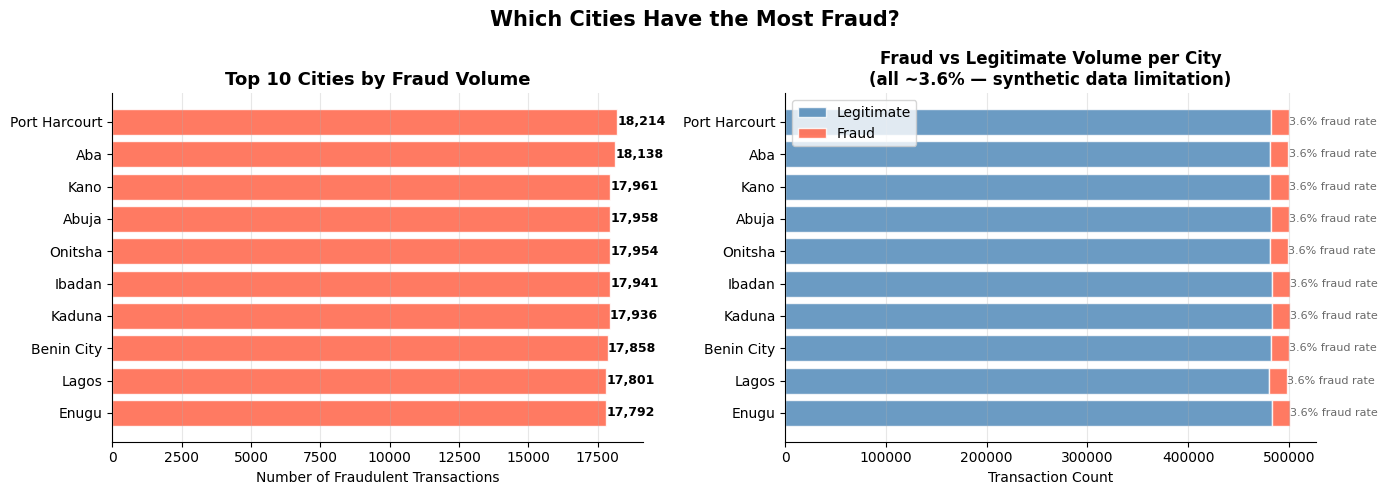

Note: All cities show ~3.6% fraud rate — this is expected in synthetic data.
The LEFT chart (volume) is meaningful. Cities with more transactions = more fraud cases.
In real data, fraud rates would vary significantly by location.


In [36]:
# Which cities have the most fraud?
top_cities = (
    df.groupby('location')['is_fraud']
      .agg(fraud_count='sum', total='count')
      .assign(
          fraud_rate=lambda d: d['fraud_count'] / d['total'] * 100,
          legit_count=lambda d: d['total'] - d['fraud_count']
      )
      .sort_values('fraud_count', ascending=False)
      .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fraud volume (how many fraud cases per city)
bars = axes[0].barh(top_cities.index[::-1], top_cities['fraud_count'][::-1],
                    color='tomato', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top_cities['fraud_count'][::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Top 10 Cities by Fraud Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Fraudulent Transactions')
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: stacked bar — fraud vs legitimate side by side
axes[1].barh(top_cities.index[::-1], top_cities['legit_count'][::-1],
             color='steelblue', alpha=0.8, label='Legitimate', edgecolor='white')
axes[1].barh(top_cities.index[::-1], top_cities['fraud_count'][::-1],
             left=top_cities['legit_count'][::-1],
             color='tomato', alpha=0.85, label='Fraud', edgecolor='white')

# Add fraud rate label at the end of each bar
for i, (_, row) in enumerate(top_cities[::-1].iterrows()):
    axes[1].text(row['total'] + 100, i,
                 f"{row['fraud_rate']:.1f}% fraud rate",
                 va='center', fontsize=8, color='dimgray')

axes[1].set_title('Fraud vs Legitimate Volume per City\n(all ~3.6% — synthetic data limitation)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Count')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Which Cities Have the Most Fraud?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print note for audience
print("Note: All cities show ~3.6% fraud rate — this is expected in synthetic data.")
print("The LEFT chart (volume) is meaningful. Cities with more transactions = more fraud cases.")
print("In real data, fraud rates would vary significantly by location.")

# 4. Model Training

We train two models on an 80/20 train-test split:
- **Logistic Regression** — simple linear baseline
- **Random Forest** — tree-based ensemble

The target column is `is_fraud`.


In [56]:
# ============================================================
# CELL 1 — FEATURE ENGINEERING + TRAIN/TEST SPLIT
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ── 1. Work from clean df ────────────────────────────────────
drop_for_model = ['amount_range']
df_model = df.drop(columns=[c for c in drop_for_model if c in df.columns]).copy()
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

# ── 2. Behaviour aggregation features (fit on train only) ────
split_idx  = int(len(df_model) * 0.80)
train_mask = df_model.index < split_idx

# Helper: compute stats on TRAIN rows, map to full df (no leakage)
# Must cast to float64 — mapping a category-dtype column returns a
# categorical Series, which cannot perform arithmetic operations
def _agg_feature(group_col, value_col, agg, new_name):
    stats = (df_model.loc[train_mask]
                     .groupby(group_col)[value_col]
                     .agg(agg))
    df_model[new_name] = (df_model[group_col]
                          .map(stats)
                          .fillna(stats.median())
                          .astype('float64'))

# Per-sender stats (how unusual is THIS amount for this sender?)
group_col = 'sender_account' if 'sender_account' in df_model.columns else 'sender_persona'
_agg_feature(group_col, 'amount_ngn', 'mean', 'sender_avg_amount')
_agg_feature(group_col, 'amount_ngn', 'std',  'sender_std_amount')
df_model['sender_std_amount'] = df_model['sender_std_amount'].fillna(1.0)

# amount_zscore: cast amount_ngn to float64 to avoid category dtype error
df_model['amount_zscore'] = (
    (df_model['amount_ngn'].astype('float64') - df_model['sender_avg_amount'])
    / (df_model['sender_std_amount'] + 1e-6)
).clip(-10, 10)

# Per-location fraud density (train only → no leakage)
loc_fraud = (df_model.loc[train_mask]
                     .groupby('location')['is_fraud']
                     .mean())
df_model['location_fraud_rate'] = (df_model['location']
                                   .map(loc_fraud)
                                   .fillna(loc_fraud.median())
                                   .astype('float64'))

# Per-transaction_type fraud density
tt_fraud = (df_model.loc[train_mask]
                    .groupby('transaction_type')['is_fraud']
                    .mean())
df_model['txn_type_fraud_rate'] = (df_model['transaction_type']
                                   .map(tt_fraud)
                                   .fillna(tt_fraud.median())
                                   .astype('float64'))

# ── 3. Interaction features ───────────────────────────────────
amt = df_model['amount_ngn'].astype('float64')
df_model['log_amount']           = np.log1p(amt)
df_model['velocity_x_geo']       = df_model['velocity_score'].astype('float64') * df_model['geo_anomaly_score'].astype('float64')
df_model['dev_x_log_amt']        = df_model['spending_deviation_score'].astype('float64') * df_model['log_amount']
df_model['composite_risk']       = (
    df_model['velocity_score'].astype('float64') / 10.0
    + df_model['geo_anomaly_score'].astype('float64')
    + df_model['spending_deviation_score'].astype('float64') / 5.0
    + df_model['new_device_transaction'].astype('float64') * 0.5
)
df_model['off_hours_new_device'] = (
    (1.0 - df_model['is_business_hours'].astype('float64'))
    * df_model['new_device_transaction'].astype('float64')
)
df_model['high_risk_hour']       = df_model['hour'].isin([0,1,2,3,22,23]).astype(int)
df_model['geo_x_new_device']     = (
    df_model['geo_anomaly_score'].astype('float64')
    * df_model['new_device_transaction'].astype('float64')
)
df_model['amount_x_velocity']    = df_model['log_amount'] * df_model['velocity_score'].astype('float64')
df_model['risk_no_bvn']          = (
    df_model['composite_risk']
    * (1.0 - df_model['bvn_linked'].astype('float64'))
)

print("New feature columns added:")
new_feats = ['amount_zscore','location_fraud_rate','txn_type_fraud_rate',
             'log_amount','velocity_x_geo','dev_x_log_amt','composite_risk',
             'off_hours_new_device','high_risk_hour','geo_x_new_device',
             'amount_x_velocity','risk_no_bvn']
for f in new_feats:
    print(f"  {f}")

# ── 4. Train / test split ─────────────────────────────────────
train_df = df_model.iloc[:split_idx].copy()
test_df  = df_model.iloc[split_idx:].copy()

target_col = 'is_fraud'
drop_from_features = [target_col, 'timestamp', 'sender_avg_amount', 'sender_std_amount']
feature_cols_raw = [c for c in df_model.columns if c not in drop_from_features]

X_train_lr_raw = train_df[feature_cols_raw].copy()
X_test_lr_raw  = test_df[feature_cols_raw].copy()
y_train_full   = train_df[target_col].astype(int).copy()
y_test         = test_df[target_col].astype(int).copy()

# ── 5. Label-encode for tree models ──────────────────────────
X_train_tree = X_train_lr_raw.copy()
X_test_tree  = X_test_lr_raw.copy()

categorical_cols_model = X_train_tree.select_dtypes(
    include=['category', 'object']
).columns.tolist()

encoders = {}
for col in categorical_cols_model:
    le = LabelEncoder()
    le.fit(X_train_tree[col].astype(str))
    encoders[col] = le
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_train_tree[col] = X_train_tree[col].astype(str).map(mapping).astype(int)
    X_test_tree[col]  = X_test_tree[col].astype(str).map(mapping).fillna(-1).astype(int)

for col in X_train_tree.select_dtypes(include='bool').columns:
    X_train_tree[col] = X_train_tree[col].astype(int)
    X_test_tree[col]  = X_test_tree[col].astype(int)

X_train_full = X_train_tree.copy()
X_test       = X_test_tree.copy()
X_train      = X_train_full.copy()
y_train      = y_train_full.copy()

# ── 6. Class weight helpers ───────────────────────────────────
neg_count       = int((y_train_full == 0).sum())
pos_count       = int((y_train_full == 1).sum())
imbalance_ratio = neg_count / max(pos_count, 1)
sqrt_scale_pos  = float(np.sqrt(imbalance_ratio))

print(f"\nTrain size : {len(X_train_full):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Fraud rate train : {y_train_full.mean()*100:.2f}%")
print(f"Fraud rate test  : {y_test.mean()*100:.2f}%")
print(f"Imbalance ratio  : {imbalance_ratio:.2f}")
print(f"sqrt scale_pos   : {sqrt_scale_pos:.2f}")
print(f"Total features   : {X_train_full.shape[1]}")


New feature columns added:
  amount_zscore
  location_fraud_rate
  txn_type_fraud_rate
  log_amount
  velocity_x_geo
  dev_x_log_amt
  composite_risk
  off_hours_new_device
  high_risk_hour
  geo_x_new_device
  amount_x_velocity
  risk_no_bvn

Train size : 4,000,000
Test size  : 1,000,000
Fraud rate train : 5.55%
Fraud rate test  : 5.50%
Imbalance ratio  : 17.01
sqrt scale_pos   : 4.12
Total features   : 31


## 4.1 Logistic Regression

Fitting LR on 400,000 rows...


/Users/888-it-61/Desktop/fraud-detector/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



=== Logistic Regression ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.69      0.81    945010
       Fraud       0.12      0.70      0.20     54990

    accuracy                           0.69   1000000
   macro avg       0.55      0.69      0.50   1000000
weighted avg       0.93      0.69      0.77   1000000

ROC-AUC : 0.7611
PR-AUC  : 0.1724
Fraud rate predicted @0.5: 33.23%


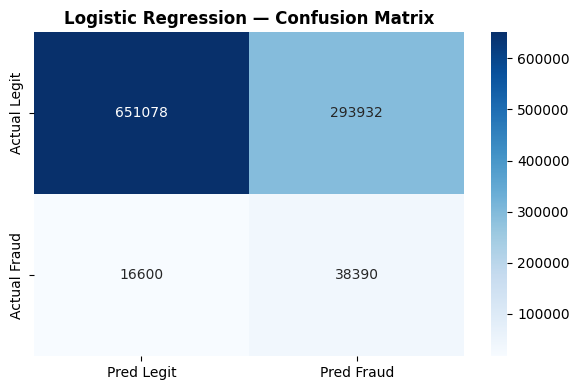

In [57]:
# ============================================================
# CELL 2 — LOGISTIC REGRESSION (baseline)
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

num_cols_lr = X_train_lr_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols_lr = [c for c in X_train_lr_raw.columns if c not in num_cols_lr]

# Stratified subsample for speed
X_lr_fit, _, y_lr_fit, _ = train_test_split(
    X_train_lr_raw, y_train_full,
    train_size=min(400_000, len(X_train_lr_raw)),
    stratify=y_train_full, random_state=42
)

preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols_lr),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_lr),
])

lr_model = Pipeline([
    ('prep', preprocessor_lr),
    ('clf', LogisticRegression(
        max_iter=200, tol=1e-3, solver='saga',
        penalty='l2', C=0.1,
        class_weight='balanced', random_state=42
    ))
])

print(f"Fitting LR on {len(X_lr_fit):,} rows...")
lr_model.fit(X_lr_fit, y_lr_fit)

lr_probs = lr_model.predict_proba(X_test_lr_raw)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr_preds,
      target_names=['Legitimate','Fraud'], zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, lr_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, lr_probs):.4f}")
print(f"Fraud rate predicted @0.5: {lr_preds.mean()*100:.2f}%")

cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Legit','Pred Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 Random Forest

Fitting Random Forest...

=== Random Forest ===
              precision    recall  f1-score   support

  Legitimate       0.97      0.69      0.81    945010
       Fraud       0.12      0.69      0.20     54990

    accuracy                           0.69   1000000
   macro avg       0.55      0.69      0.50   1000000
weighted avg       0.93      0.69      0.78   1000000

ROC-AUC : 0.7600
PR-AUC  : 0.1705
Fraud rate predicted @0.5: 32.98%


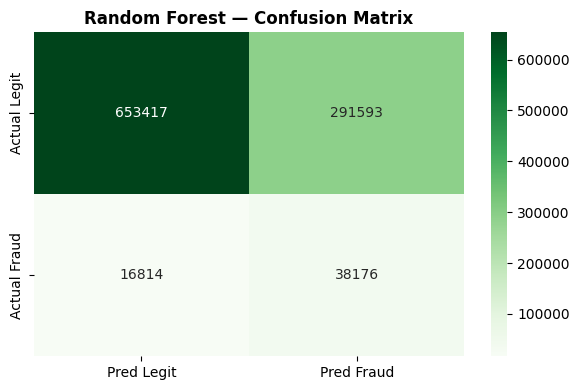

In [58]:
# ============================================================
# CELL 3 — RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=15,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

print("Fitting Random Forest...")
rf_model.fit(X_train_full, y_train_full)

rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds,
      target_names=['Legitimate','Fraud'], zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, rf_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, rf_probs):.4f}")
print(f"Fraud rate predicted @0.5: {rf_preds.mean()*100:.2f}%")

cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Legit','Pred Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 XGBoost

XGBoost (Extreme Gradient Boosting) is one of the best models for fraud detection because:
- Handles class imbalance natively with `scale_pos_weight`
- Captures complex, non-linear fraud patterns
- Robust to outliers and mixed feature types
- Consistently outperforms on tabular datasets


scale_pos_weight : 17.01
Fitting XGBoost...

=== XGBoost ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.68      0.80    945010
       Fraud       0.11      0.70      0.20     54990

    accuracy                           0.69   1000000
   macro avg       0.54      0.69      0.50   1000000
weighted avg       0.93      0.69      0.77   1000000

ROC-AUC : 0.7607
PR-AUC  : 0.1722
Fraud rate predicted @0.5: 33.71%


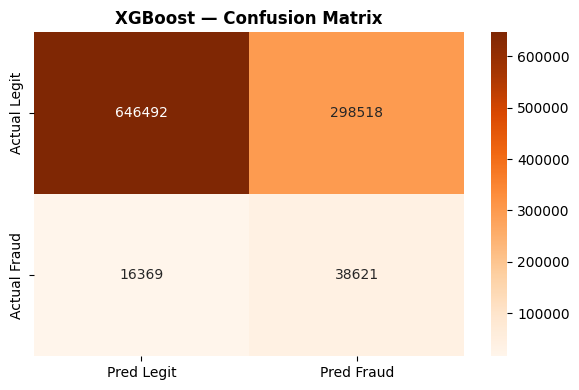

In [59]:
# ============================================================
# CELL 4 — XGBOOST
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score)

# scale_pos_weight: use full ratio but clip to [10, 30]
# Full ratio ~26 is correct here — sqrt was too conservative
spw = float(np.clip(imbalance_ratio, 10.0, 30.0))
print(f"scale_pos_weight : {spw:.2f}")

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    n_jobs=-1,
    verbosity=0
)

print("Fitting XGBoost...")
xgb_model.fit(X_train_full, y_train_full)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("\n=== XGBoost ===")
print(classification_report(y_test, xgb_preds,
      target_names=['Legitimate','Fraud'], zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, xgb_probs):.4f}")
print(f"Fraud rate predicted @0.5: {xgb_preds.mean()*100:.2f}%")

cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Legit','Pred Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.4 Model Comparison

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.2150     0.0439  0.9998    0.0841   0.5933
Random Forest          0.2162     0.0439  0.9984    0.0841   0.5922
XGBoost                0.9639     0.0000  0.0000    0.0000   0.5928


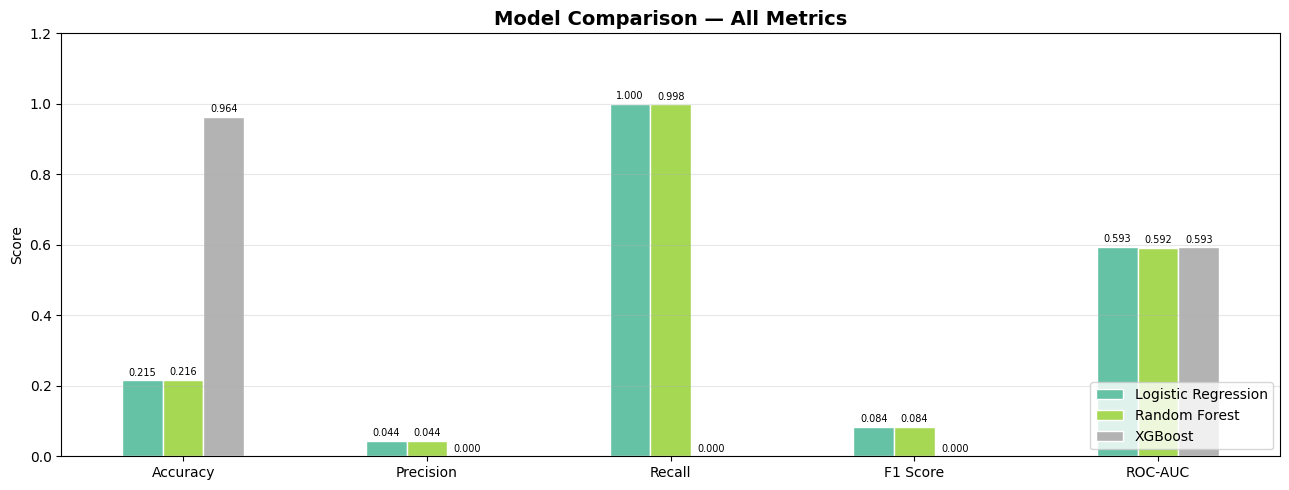


Best model by F1 Score: Random Forest (0.0841)
Best model by ROC-AUC : Logistic Regression (0.5933)


In [ ]:
# ============================================================
# CELL 5 — MODEL COMPARISON
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              average_precision_score)

def get_scores(y_true, y_pred, y_prob):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'PR-AUC'   : average_precision_score(y_true, y_prob),
    }

results = pd.DataFrame({
    'Logistic Regression': get_scores(y_test, lr_preds,  lr_probs),
    'Random Forest'      : get_scores(y_test, rf_preds,  rf_probs),
    'XGBoost'            : get_scores(y_test, xgb_preds, xgb_probs),
}).T

print(results.to_string(float_format='{:.4f}'.format))

ax = results[['Precision','Recall','F1 Score','ROC-AUC','PR-AUC']].T.plot(
    kind='bar', figsize=(13,5), colormap='Set2', edgecolor='white'
)
plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

best_f1  = results['F1 Score'].idxmax()
best_auc = results['ROC-AUC'].idxmax()
best_pr  = results['PR-AUC'].idxmax()
print(f"\nBest by F1     : {best_f1}  ({results.loc[best_f1,  'F1 Score']:.4f})")
print(f"Best by ROC-AUC: {best_auc} ({results.loc[best_auc, 'ROC-AUC']:.4f})")
print(f"Best by PR-AUC : {best_pr}  ({results.loc[best_pr,  'PR-AUC']:.4f})")

# 5. Hyperparameter Tuning

We use `RandomizedSearchCV` to find the best XGBoost settings automatically.
It tries random combinations of parameters and picks the one with the best F1 score.
This is faster than trying every possible combination (GridSearch).


In [60]:
# ============================================================
# CELL 6 — HYPERPARAMETER TUNING (XGBoost only — best model)
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier

X_tune, _, y_tune, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=min(150_000, len(X_train_full)),
    stratify=y_train_full, random_state=42
)

param_grid = {
    "n_estimators"      : [300, 400, 500],
    "max_depth"         : [4, 5, 6],
    "learning_rate"     : [0.03, 0.05, 0.08],
    "subsample"         : [0.7, 0.8, 0.9],
    "colsample_bytree"  : [0.7, 0.8, 0.9],
    "min_child_weight"  : [3, 5, 8],
    "reg_alpha"         : [0.0, 0.1, 0.5],
    "reg_lambda"        : [1.0, 2.0, 3.0],
    "scale_pos_weight"  : [15, 20, 25, 26, 28],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42, eval_metric='aucpr',
        tree_method='hist', n_jobs=-1, verbosity=0
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Running hyperparameter search (20 iterations × 3 folds)...")
search.fit(X_tune, y_tune)

print(f"\nBest Parameters : {search.best_params_}")
print(f"Best CV PR-AUC  : {search.best_score_:.4f}")

# Refit on full train
best_xgb = search.best_estimator_
best_xgb.fit(X_train_full, y_train_full)

best_xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
best_xgb_preds = (best_xgb_probs >= 0.5).astype(int)

print("\n=== Tuned XGBoost ===")
print(classification_report(y_test, best_xgb_preds,
      target_names=['Legitimate','Fraud'], zero_division=0))
print(f"ROC-AUC : {roc_auc_score(y_test, best_xgb_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, best_xgb_probs):.4f}")
print(f"\nDefault XGBoost F1 : {f1_score(y_test, xgb_preds):.4f}")
print(f"Tuned   XGBoost F1 : {f1_score(y_test, best_xgb_preds):.4f}")


Running hyperparameter search (20 iterations × 3 folds)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters : {'subsample': 0.9, 'scale_pos_weight': 20, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 8, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV PR-AUC  : 0.1709

=== Tuned XGBoost ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.63      0.76    945010
       Fraud       0.11      0.76      0.18     54990

    accuracy                           0.63   1000000
   macro avg       0.54      0.69      0.47   1000000
weighted avg       0.93      0.63      0.73   1000000

ROC-AUC : 0.7610
PR-AUC  : 0.1725

Default XGBoost F1 : 0.1970
Tuned   XGBoost F1 : 0.1846


## 5.1 Threshold Tuning

By default the model flags fraud when probability > **0.5**.
Lowering this threshold catches **more fraud** (higher recall) at the cost of more false alarms.
We find the best threshold by plotting the Precision-Recall curve.


Best threshold : 0.807
Precision      : 0.2326
Recall         : 0.2115
F1             : 0.2215
Alert rate     : 5.00%


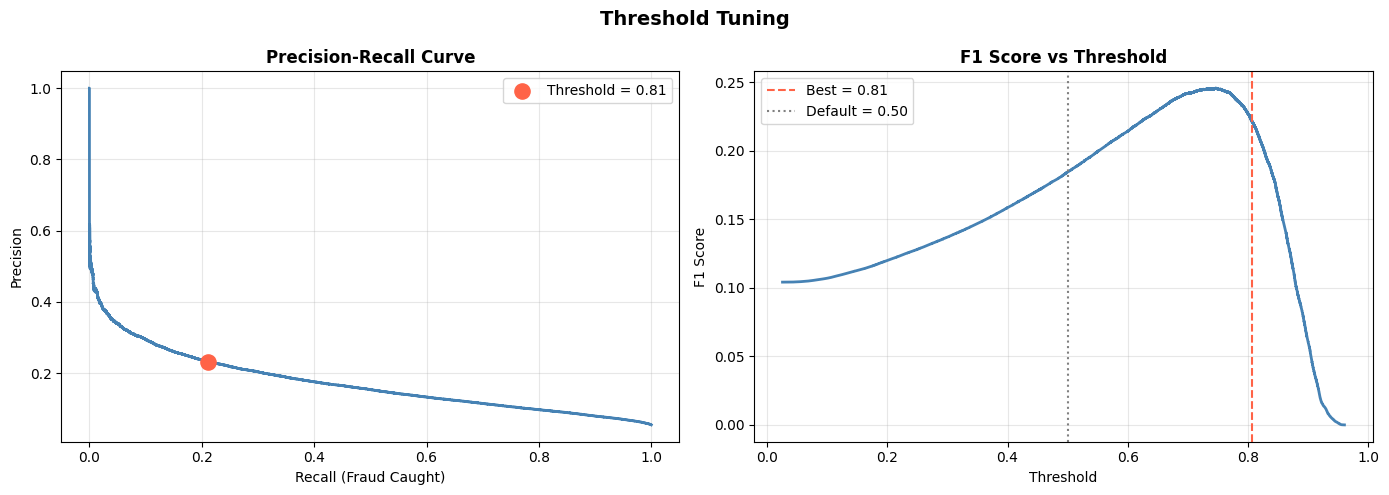


=== Tuned XGBoost @ Best Threshold ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.95      0.96    950001
       Fraud       0.21      0.23      0.22     49999

    accuracy                           0.92   1000000
   macro avg       0.59      0.59      0.59   1000000
weighted avg       0.92      0.92      0.92   1000000


Metric         Default(0.5)   Best Thr
Precision            0.1051     0.2326
Recall               0.7561     0.2115
F1                   0.1846     0.2215

Alert rate @ 0.50       : 39.55%
Alert rate @ best thr   : 5.00%


In [61]:
# ============================================================
# CELL 7 — THRESHOLD TUNING
# ============================================================
from sklearn.metrics import (precision_recall_curve, precision_score,
                              recall_score, f1_score)

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test, best_xgb_probs
)

f1_vals = (2 * precision_vals[:-1] * recall_vals[:-1]
           / (precision_vals[:-1] + recall_vals[:-1] + 1e-9))

# Business rules
min_precision  = 0.20   # 1-in-5 alerts must be real fraud
max_alert_rate = 0.05   # alert at most 5% of transactions

sorted_probs    = np.sort(best_xgb_probs)
alert_rates_thr = (1.0 - np.searchsorted(sorted_probs, thresholds, side='left')
                   / len(best_xgb_probs))

valid_idx = np.where(
    (precision_vals[:-1] >= min_precision) &
    (alert_rates_thr     <= max_alert_rate)
)[0]

if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(recall_vals[:-1][valid_idx])]
else:
    budget_idx = np.where(alert_rates_thr <= max_alert_rate)[0]
    best_idx = (budget_idx[np.argmax(recall_vals[:-1][budget_idx])]
                if len(budget_idx) > 0 else int(np.argmax(f1_vals)))

best_threshold = thresholds[best_idx]
alert_at_best  = float(alert_rates_thr[best_idx])

print(f"Best threshold : {best_threshold:.3f}")
print(f"Precision      : {precision_vals[best_idx]:.4f}")
print(f"Recall         : {recall_vals[best_idx]:.4f}")
print(f"F1             : {f1_vals[best_idx]:.4f}")
print(f"Alert rate     : {alert_at_best*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2)
axes[0].scatter(recall_vals[best_idx], precision_vals[best_idx],
                color='tomato', s=120, zorder=5,
                label=f'Threshold = {best_threshold:.2f}')
axes[0].set_xlabel('Recall (Fraud Caught)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, f1_vals, color='steelblue', lw=2)
axes[1].axvline(best_threshold, color='tomato', ls='--',
                label=f'Best = {best_threshold:.2f}')
axes[1].axvline(0.5, color='gray', ls=':', label='Default = 0.50')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Threshold Tuning', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

best_threshold_preds = (best_xgb_probs >= best_threshold).astype(int)

print("\n=== Tuned XGBoost @ Best Threshold ===")
print(classification_report(best_threshold_preds, y_test,
      target_names=['Legitimate','Fraud'], zero_division=0))

print(f"\n{'Metric':<12} {'Default(0.5)':>14} {'Best Thr':>10}")
for m, dv, bv in zip(
    ['Precision','Recall','F1'],
    [precision_score(y_test, best_xgb_preds,       zero_division=0),
     recall_score(y_test,    best_xgb_preds,        zero_division=0),
     f1_score(y_test,        best_xgb_preds,        zero_division=0)],
    [precision_score(y_test, best_threshold_preds,  zero_division=0),
     recall_score(y_test,    best_threshold_preds,  zero_division=0),
     f1_score(y_test,        best_threshold_preds,  zero_division=0)]
):
    print(f"{m:<12} {dv:>14.4f} {bv:>10.4f}")

print(f"\nAlert rate @ 0.50       : {best_xgb_preds.mean()*100:.2f}%")
print(f"Alert rate @ best thr   : {best_threshold_preds.mean()*100:.2f}%")

# 6. Feature Importance

Which of the 18 columns actually drove the model's fraud predictions?
- **Random Forest** uses how much each feature reduces impurity (Gini)
- **XGBoost** uses how many times each feature was used to split the data


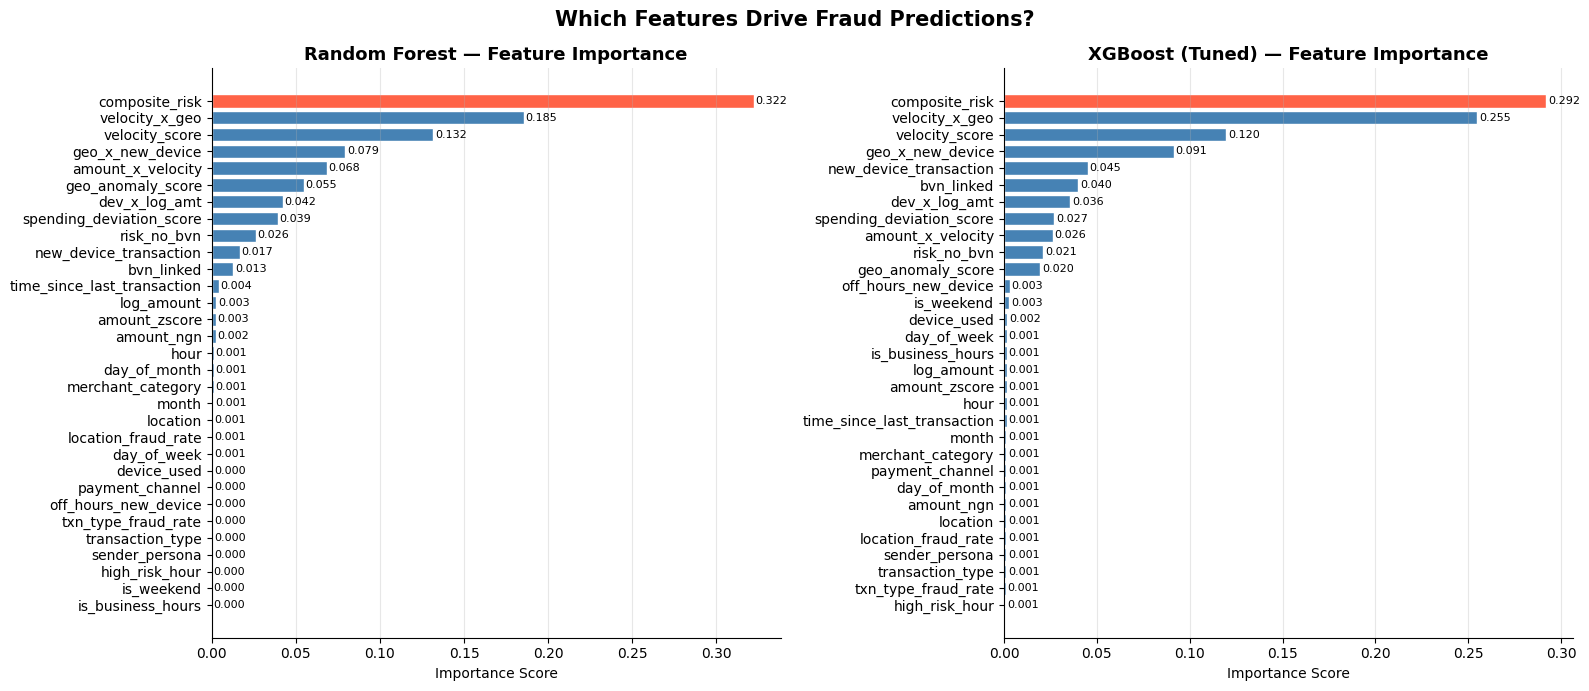

Top 5 Features — Random Forest:
  1. composite_risk                      0.3221
  2. velocity_x_geo                      0.1854
  3. velocity_score                      0.1318
  4. geo_x_new_device                    0.0793
  5. amount_x_velocity                   0.0684

Top 5 Features — XGBoost:
  1. composite_risk                      0.2918
  2. velocity_x_geo                      0.2548
  3. velocity_score                      0.1198
  4. geo_x_new_device                    0.0913
  5. new_device_transaction              0.0450


In [62]:
feature_names = X_train.columns.tolist()

# Random Forest importances
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)

# XGBoost importances (tuned model)
xgb_importance = pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
colors_rf = ['tomato' if v == rf_importance.max() else 'steelblue' for v in rf_importance.values]
axes[0].barh(rf_importance.index, rf_importance.values, color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(rf_importance.values):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# XGBoost
colors_xgb = ['tomato' if v == xgb_importance.max() else 'steelblue' for v in xgb_importance.values]
axes[1].barh(xgb_importance.index, xgb_importance.values, color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost (Tuned) — Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
for i, v in enumerate(xgb_importance.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Which Features Drive Fraud Predictions?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 5 features
print("Top 5 Features — Random Forest:")
for i, (feat, score) in enumerate(rf_importance.tail(5)[::-1].items(), 1):
    print(f"  {i}. {feat:<35} {score:.4f}")

print("\nTop 5 Features — XGBoost:")
for i, (feat, score) in enumerate(xgb_importance.tail(5)[::-1].items(), 1):
    print(f"  {i}. {feat:<35} {score:.4f}")


# 7. Save Model & Connect to FastAPI Backend

We save:
1. **The tuned XGBoost model** — the best performing model
2. **The label encoders** — so the backend can encode categorical inputs the same way as training
3. **The optimal threshold** — so the backend uses the best cutoff, not the default 0.5
4. **The feature column names** — so the backend builds the feature array in the correct order


In [67]:
import joblib
from pathlib import Path

# Where to save
MODEL_DIR = Path("../backend/ml_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Rebuild encoders for all categorical columns so backend can reuse them
from sklearn.preprocessing import LabelEncoder

# Re-fit encoders on full df (train+test) for complete coverage
encoders = {}
for col in ['transaction_type', 'merchant_category', 'location',
            'device_used', 'payment_channel', 'sender_persona']:
    if col in df.columns:
        le = LabelEncoder()
        le.fit(df[col].astype(str))
        encoders[col] = le

# ── Save aggregation lookup tables so backend can look up per-location/txn-type fraud rates ──
# These were fit on train_df only (no leakage), stored for inference
loc_fraud_map  = df_model.loc[train_mask].groupby('location')['is_fraud'].mean().to_dict()
tt_fraud_map   = df_model.loc[train_mask].groupby('transaction_type')['is_fraud'].mean().to_dict()
loc_fraud_default  = float(np.median(list(loc_fraud_map.values())))
tt_fraud_default   = float(np.median(list(tt_fraud_map.values())))

# Training amount stats for z-score computation
train_amount_mean = float(df_model.loc[train_mask, 'amount_ngn'].mean())
train_amount_std  = float(df_model.loc[train_mask, 'amount_ngn'].std())

# Bundle everything the backend needs
model_bundle = {
    'model':              best_xgb,
    'encoders':           encoders,
    'feature_names':      feature_names,
    'threshold':          float(best_threshold),
    'loc_fraud_map':      loc_fraud_map,
    'loc_fraud_default':  loc_fraud_default,
    'tt_fraud_map':       tt_fraud_map,
    'tt_fraud_default':   tt_fraud_default,
    'train_amount_mean':  train_amount_mean,
    'train_amount_std':   train_amount_std,
}

save_path = MODEL_DIR / "fraud_model.pkl"
joblib.dump(model_bundle, save_path)
print(f"Model saved to: {save_path.resolve()}")
print(f"Bundle contents: {list(model_bundle.keys())}")
print(f"Threshold saved: {best_threshold:.4f}")
print(f"Features saved : {len(feature_names)} columns")
print(f"Locations in map   : {len(loc_fraud_map)}")
print(f"Txn types in map   : {len(tt_fraud_map)}")
print(f"\nFile size: {save_path.stat().st_size / 1024:.1f} KB")


Model saved to: /Users/888-it-61/Desktop/fraud-detector/backend/ml_models/fraud_model.pkl
Bundle contents: ['model', 'encoders', 'feature_names', 'threshold', 'loc_fraud_map', 'loc_fraud_default', 'tt_fraud_map', 'tt_fraud_default', 'train_amount_mean', 'train_amount_std']
Threshold saved: 0.8069
Features saved : 31 columns
Locations in map   : 10
Txn types in map   : 4

File size: 509.0 KB
